# Customer service ticket triage, built four ways

**Peter Mathews**

One job, done four ways, then compared on cost and accuracy. The job: a support
ticket comes in, sometimes with an attachment. Figure out what it's about, how
urgent it is, pull any data off the attachment, and route it to the right team.

I built it as a rules script, a trained ML model, a single Claude call, and a
LangGraph agent. The point isn't any one of them. It's knowing which one fits a
given step, and being able to show why with numbers.

| Version | Stack | What it covers |
| --- | --- | --- |
| A. Rules | Python, regex | Keyword matching and a regex receipt parser |
| B. Classic ML | pandas, scikit-learn | TF-IDF with logistic regression, plus an MLP neural net |
| C. GenAI | Claude API, structured output | One call classifies and extracts, no training data |
| D. Agent | LangGraph + Claude | A graph that routes by intent and what's attached |


## 1. The process, before any model

Write down what happens today and who does it. Every AI project is really a
process with people and tools around it. The model is one box.

| Layer | What it looks like today |
| --- | --- |
| People | Frontline agents read each ticket, guess the queue, open attachments by hand, escalate upset customers on instinct. |
| Process | Ticket comes in, someone reads it, classifies it, checks sentiment and priority, opens any receipt or photo to pull details, routes it, acts. |
| Technology | A shared inbox and a ticketing tool. Routing is judgment. Nothing gets measured. |

Then the question worth answering: which of those steps should be a rule, which
a trained model, which an LLM call, which an agent, and what does each cost.

Notice we wrote the process down before touching a model. Half the value is
realizing a step doesn't need ML at all.


In [1]:
# setup
# Local: run from the notebooks/ folder.
# Colab: clone the repo first, then point sys.path at its src/ folder.
import os, sys
SRC = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if not os.path.isdir(SRC):
    SRC = os.path.abspath("src")
sys.path.insert(0, SRC)

import warnings; warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import train_test_split

from approach_b_ml import load_data
df = load_data()
print(f"{len(df)} tickets loaded")
df.head(3)


240 tickets loaded


,id,text,intent,sentiment,attachment_type,attachment_content
0,T0089,"I can't get the export feature to work, it jus...",technical_issue,neutral,none,
1,T0178,I'm locked out of my account and the reset ema...,account_access,negative,none,
2,T0187,Good morning. This is the third time I've cont...,complaint,negative,none,


## 2. A look at the data

Labelled support tickets, some with an attached receipt or photo. The data is
synthetic on purpose. Real ticket queues are proprietary, which is the reason a
public demo has to make its own. Swapping in a real public dataset like
HuggingFace banking77 is a one cell change.


In [2]:
print("Tickets per intent:")
print(df["intent"].value_counts().to_string())
print("\nSentiment mix:", df["sentiment"].value_counts().to_dict())
print("Attachments:", df["attachment_type"].value_counts().to_dict())


Tickets per intent:
intent
technical_issue     30
account_access      30
complaint           30
billing_question    30
refund_request      30
order_status        30
damaged_product     30
general_inquiry     30

Sentiment mix: {'neutral': 133, 'negative': 97, 'positive': 10}
Attachments: {'none': 195, 'image': 23, 'document': 22}


In [3]:
# A few tickets, including one with a receipt.
for _, r in df[df.attachment_type == "document"].head(1).iterrows():
    print("TICKET:", r.text)
    print("ATTACHED DOCUMENT:\n", r.attachment_content)


TICKET: Good morning. I was billed twice, please refund order A29410.
ATTACHED DOCUMENT:
 ORDER CONFIRMATION
Order #: A29410
Date: 2026-01-19
Item: Wireless Headphones
Total: $113.98
Thank you for your purchase!


In [4]:
# One train/test split, reused by every version so the comparison is fair.
train, test = train_test_split(df, test_size=0.3, random_state=42, stratify=df["intent"])
print(f"train={len(train)}  test={len(test)}")


train=168  test=72


## 3. Version A: rules

Keyword lists for intent, a word list for sentiment, regex for the receipt. This
is where most teams actually start. It's instant, free, and easy to follow. It
breaks the moment a customer phrases something nobody added to the keyword list.


In [5]:
import approach_a_rules as rules
from evaluate import evaluate_offline

sample = "Hi team, my order A12345 arrived cracked, photo attached. Pretty upset."
print(rules.triage(sample, "image", "photo_damaged").to_dict())

m = evaluate_offline(test, rules.triage)
print(f"\nrules: intent {m['intent_acc']:.1%}, sentiment {m['sentiment_acc']:.1%}, "
      f"{m['latency_ms']:.3f} ms/ticket")


{'intent': 'damaged_product', 'sentiment': 'neutral', 'priority': 'normal', 'route': 'Returns & Quality', 'action': 'Inspect photo, open return, send replacement', 'extracted': {'order_id': None, 'amount': None, 'order_date': None}, 'image_label': 'damaged'}

rules: intent 81.9%, sentiment 47.2%, 0.011 ms/ticket


This score is the bar. If a trained model can't beat a morning of keyword
writing, it isn't worth the extra complexity. Make the team prove the lift.


## 4. Version B: classic ML

Learn intent and sentiment from labelled data instead of writing rules. Two
models on the same pipeline, so you can see how scikit-learn composes: TF-IDF
into a classifier.

- Logistic regression, the cheap strong baseline.
- MLPClassifier, a small neural network, one of the four ML concepts to teach.


In [6]:
from approach_b_ml import MLTriager

for model in ("logreg", "mlp"):
    t = MLTriager(intent_model=model, sentiment_model=model).fit(train)
    m = evaluate_offline(test, t.triage)
    print(f"{model:7s}: intent {m['intent_acc']:.1%}, sentiment {m['sentiment_acc']:.1%}")


logreg : intent 95.8%, sentiment 59.7%


mlp    : intent 100.0%, sentiment 48.6%


The neural net is not automatically better. On a small dataset it's higher
variance and can trail the linear baseline on the harder label. "Use the deep
model" is a decision to justify, not a default. This is the kind of result I'd
have a team explain rather than wave past.


### 4b. Image classification

When the attachment is a photo, you have to look at pixels, not text. That's
image classification, the fourth ML concept. Real product photos need a labelled
image set we can't ship, so this trains on scikit-learn's digits (real 8x8
images) with the same pipeline you'd use on photos: pixels, split, neural net,
evaluate.


In [7]:
from image_classifier import train_image_classifier
_, img_acc = train_image_classifier()
print(f"Image classifier (digits stand-in) test accuracy: {img_acc:.1%}")


Image classifier (digits stand-in) test accuracy: 96.7%


## 5. Version C: GenAI with Claude

One Claude call classifies intent and sentiment and, when a receipt is attached,
extracts its fields in the same shot. No training data. messages.parse() with a
Pydantic schema guarantees valid structured output, so there's no fragile JSON
parsing. The model tier is a cost dial.

The cell runs live if ANTHROPIC_API_KEY is set, otherwise it just shows how. Code
is in [src/approach_c_genai.py](../src/approach_c_genai.py).


In [8]:
import os
if os.getenv("ANTHROPIC_API_KEY"):
    from approach_c_genai import GenAITriager
    t = GenAITriager(tier="haiku")
    receipt = ("ORDER CONFIRMATION\nOrder #: A55512\nDate: 2026-03-14\n"
               "Item: Wireless Headphones\nTotal: $129.99")
    out = t.triage("I want my money back, the headphones broke.", "document", receipt)
    print(out.to_dict())
    print("tokens (in, out):", t.last_usage)
else:
    print("Set ANTHROPIC_API_KEY to run Claude live.")
    print("The model reads the ticket and the receipt and returns a validated")
    print("result: intent, sentiment, and the extracted order fields.")


Set ANTHROPIC_API_KEY to run Claude live.
The model reads the ticket and the receipt and returns a validated
result: intent, sentiment, and the extracted order fields.


The receipt extraction is the tell. The rules version only works because it
knows the receipt's exact layout. Change the format and it returns nothing. The
LLM reads a receipt it has never seen. That capability, not raw accuracy, is what
pays for the per call cost.


## 6. Version D: an agent in LangGraph

The same job, but as a graph that branches. After classifying, the path depends
on the intent and what's attached.

```
classify, then:
  document attached      -> extract receipt fields -+
  image attached         -> classify the photo      |
  complaint and negative -> escalate                 +-> route and act
  nothing attached       ----------------------------+
```

That branching, where the action depends on the ticket and the attachment, is
what an agent framework handles cleanly and a flat pipeline doesn't. Code is in
[src/approach_d_agent.py](../src/approach_d_agent.py).


In [9]:
import os
if os.getenv("ANTHROPIC_API_KEY"):
    try:
        from approach_d_agent import build_agent, triage as agent_triage
        agent = build_agent(model_tier="haiku")
        receipt = "ORDER CONFIRMATION\nOrder #: A55512\nDate: 2026-03-14\nTotal: $129.99"
        print(agent_triage(agent, "Please refund me, item never worked.", "document", receipt).to_dict())
    except ImportError:
        print("pip install langgraph langchain-anthropic to run the agent.")
else:
    print("Set ANTHROPIC_API_KEY and pip install langgraph langchain-anthropic to run the agent.")
    print("The graph routes the receipt ticket through classify, extract, finalize.")


Set ANTHROPIC_API_KEY and pip install langgraph langchain-anthropic to run the agent.
The graph routes the receipt ticket through classify, extract, finalize.


## 7. The comparison table

Same job, four versions, one table. The offline rows are measured. The GenAI
rows show cost from real published pricing (Haiku $1/$5, Sonnet $3/$15, Opus
$5/$25 per million tokens) and a representative token count. Run
`python src/evaluate.py --live` to fill in measured GenAI accuracy too.


In [10]:
from evaluate import build_matrix
matrix = build_matrix(live=bool(os.getenv("ANTHROPIC_API_KEY")))
pd.set_option("display.max_columns", None)
matrix


,approach,intent_acc,sentiment_acc,doc_extract_acc,latency_ms,cost_per_1k_$,training_data,extraction,images,explainability
0,A. Rules / regex,0.819444,0.472222,1.0,0.030857,0.00,none,regex (brittle),filename only,total
1,"B. ML, TF-IDF + LogReg",0.958333,0.597222,1.0,0.716580,0.00,needs labels,regex (brittle),needs labelled photos,medium
2,"B. ML, neural net (MLP)",1.000000,0.486111,1.0,0.439738,0.00,needs labels,regex (brittle),needs labelled photos,medium
3,"C. GenAI, Claude haiku",NaN,NaN,NaN,NaN,0.37,none (zero-shot),"zero-shot, robust",vision-capable,low
4,"C. GenAI, Claude sonnet",NaN,NaN,NaN,NaN,1.11,none (zero-shot),"zero-shot, robust",vision-capable,low
5,"C. GenAI, Claude opus",NaN,NaN,NaN,NaN,1.85,none (zero-shot),"zero-shot, robust",vision-capable,low


## 7b. Where it runs and what it costs at scale

Accuracy is half the call. The other half is where it runs and how it's billed,
which is a cloud question. Each version maps to a managed service, and the cost
models cross over. Full write up in
[docs/deployment_and_cost.md](../docs/deployment_and_cost.md).

| Version | AWS | Google Cloud | Azure | How it bills |
| --- | --- | --- | --- | --- |
| Rules | Lambda | Cloud Functions | Azure Functions | per invocation, basically free |
| Classic ML | SageMaker | Vertex AI | Azure ML | instance hour, or per request |
| GenAI (Claude) | Bedrock | Vertex Model Garden | Azure AI Foundry | per token, Batch about half price |
| Agent | Bedrock, or API plus tools | Vertex Agent Builder | Azure AI Agent Service | tokens plus orchestration |

Claude runs on Bedrock, Vertex, Foundry, and the Anthropic API. Same
messages.parse() code, just a different client and model id
([src/providers.py](../src/providers.py)). So provider choice is procurement and
compliance, not a rewrite.


In [11]:
from tco import build_tco_table
build_tco_table()


,approach,"$10,000/mo","$100,000/mo","$1,000,000/mo","$10,000,000/mo"
0,Rules → serverless (Lambda/Functions),0.0,0.04,0.4,4.0
1,Classic ML → provisioned endpoint,88.0,88.00,88.0,88.0
2,Classic ML → serverless inference,0.5,5.00,50.0,500.0
3,Claude Haiku (per-token),3.7,37.00,370.0,3700.0
4,Claude Sonnet (per-token),11.1,111.00,1110.0,11100.0
5,Claude Opus (per-token),18.5,185.00,1850.0,18500.0


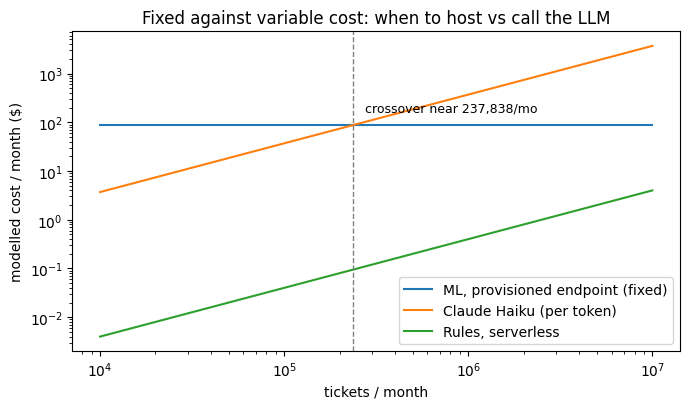

Below about 237,838 tickets/mo, call Haiku. Above, host the trained model.


In [12]:
# The crossover: fixed cost endpoint against per token LLM.
import matplotlib.pyplot as plt
from tco import monthly_cost, crossover_volume, llm_cost_per_ticket, ML_ENDPOINT_MONTHLY

vols = [10_000 * (10 ** (i / 10)) for i in range(31)]  # 10k to 10M, log spaced
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(vols, [monthly_cost("ml_endpoint", v) for v in vols], label="ML, provisioned endpoint (fixed)")
ax.plot(vols, [monthly_cost("genai_haiku", v) for v in vols], label="Claude Haiku (per token)")
ax.plot(vols, [monthly_cost("rules_serverless", v) for v in vols], label="Rules, serverless")
xo = crossover_volume(ML_ENDPOINT_MONTHLY, llm_cost_per_ticket("haiku"))
ax.axvline(xo, color="grey", ls="--", lw=1)
ax.annotate(f"crossover near {xo:,.0f}/mo", (xo, ML_ENDPOINT_MONTHLY), textcoords="offset points",
            xytext=(8, 10), fontsize=9)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("tickets / month"); ax.set_ylabel("modelled cost / month ($)")
ax.set_title("Fixed against variable cost: when to host vs call the LLM")
ax.legend(); fig.tight_layout(); plt.show()
print(f"Below about {xo:,.0f} tickets/mo, call Haiku. Above, host the trained model.")


The cheapest option per call is often the most expensive to own, once you add
training, labelling, endpoints, and maintenance (the checklist is in the doc).
Making a team put a dollar figure on each row, and name the AWS or GCP service
they'd actually deploy on, is the work.


## 8. So what would I tell the team

No single version wins, and that's the point.

- Rules win when the patterns are stable and a miss is cheap. Free, instant, easy
  to audit. Start here and keep them for the easy 60 percent.
- Classic ML wins on high volume, stable label classification once you have
  labelled data. Near zero inference cost is decisive at a million tickets a
  month. It can't read a new receipt format or a photo without a lot more
  labelled data, and it needs that data to exist at all.
- GenAI wins on the long tail and on extraction, new phrasings, reading documents
  and photos with no training. It costs real money per call, so use it where the
  flexibility pays: the messy cases and the attachments.
- The agent wins when the process itself branches, different actions for
  different intents and attachments. It's orchestration, not a smarter model.

What I'd actually ship: rules and a cheap ML model handle the bulk, the ambiguous
tickets and all attachments go to a Haiku or agent path, and Sonnet or Opus is
held back for the hardest cases. That blend, not "use the biggest model," is the
call this notebook is meant to teach a team to make.
